# Bivariate Exploratory Data Analysis

In this notebook I will perform bivariate analysis to understand the relationship between features and the target variable 

## Setup and Data Loading

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from scipy.stats import (ttest_ind, mannwhitneyu, f_oneway, kruskal,
                         chi2_contingency, fisher_exact, pointbiserialr)
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from eda_utils import spearman_trend, cramers_v

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [18]:
df = pd.read_parquet("../data/silver/data_to_bivar.parquet", engine='pyarrow')
df = df.sort_values(["date", "time"]).reset_index(drop=True)
df.head()

,date,time,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled
0,2024-01-01,00:19:34,Bike,Udyog Vihar,Ambience Mall,10.8,0
1,2024-01-01,01:35:18,Go Mini,Basai Dhankot,Madipur,8.5,0
2,2024-01-01,01:37:50,Go Sedan,Tughlakabad,Greater Kailash,7.4,1
3,2024-01-01,01:48:03,Auto,Palam Vihar,Kherki Daula Toll,5.6,1
4,2024-01-01,01:49:56,Go Sedan,Narsinghpur,Pulbangash,6.2,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   date             150000 non-null  object  
 1   time             150000 non-null  object  
 2   vehicle_type     150000 non-null  category
 3   pickup_location  150000 non-null  category
 4   drop_location    150000 non-null  category
 5   avg_vtat         139500 non-null  float32 
 6   is_cancelled     150000 non-null  int64   
dtypes: category(3), float32(1), int64(1), object(2)
memory usage: 4.7+ MB


## Temporal features

Temporal features are not directly usable by models but they can contain powerful temporal patterns so let's see if we can discover seasonal effects, temporal drift, time-of-day effects, etc.

### date vs target

Let's check if there are trends, seasonability or anomalies in cancellation rate over time

In [20]:

daily = df[["date", "is_cancelled"]].copy()

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.groupby("date").agg(is_cancelled=("is_cancelled", "sum"), total=("is_cancelled", "count")).reset_index()

daily["cancel_rate"] = daily["is_cancelled"] / daily["total"]
daily["rolling_7d"] = daily["cancel_rate"].rolling(window=7, center=True).mean()
daily["rolling_30d"] = daily["cancel_rate"].rolling(window=30, center=True).mean()
daily["weekday"] = daily["date"].dt.dayofweek

daily.head()

,date,is_cancelled,total,cancel_rate,rolling_7d,rolling_30d,weekday
0,2024-01-01,142,414,0.342995,NaN,NaN,0
1,2024-01-02,131,389,0.336761,NaN,NaN,1
2,2024-01-03,115,384,0.299479,NaN,NaN,2
3,2024-01-04,133,414,0.321256,0.327605,NaN,3
4,2024-01-05,134,416,0.322115,0.319211,NaN,4


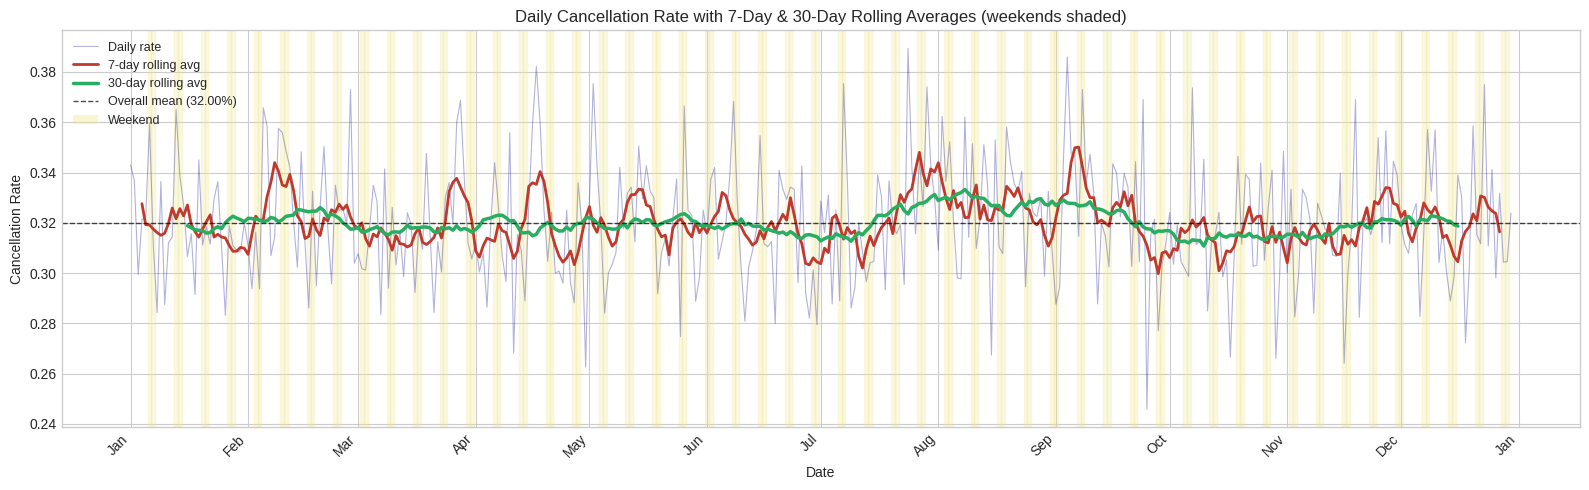

In [21]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily["date"], daily["cancel_rate"],
        alpha=0.30, color="darkblue", linewidth=0.8, label="Daily rate")
ax.plot(daily["date"], daily["rolling_7d"],
        color="#c0392b", linewidth=2, label="7-day rolling avg")
ax.plot(daily["date"], daily["rolling_30d"],
        color="#27ae60", linewidth=2.5, label="30-day rolling avg")
ax.axhline(daily["cancel_rate"].mean(), color="black", ls="--",
           lw=1, alpha=0.7,
           label=f'Overall mean ({daily["cancel_rate"].mean():.2%})')

for _, row in daily.iterrows():
    if row["weekday"] >= 5:  # Saturday or Sunday
        ax.axvspan(row["date"] - pd.Timedelta(hours=12),
                   row["date"] + pd.Timedelta(hours=12),
                   color="#f0e68c", alpha=0.25)

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="#f0e68c", alpha=0.4, label="Weekend"))
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.set_ylabel("Cancellation Rate")
ax.set_xlabel("Date")
ax.set_title("Daily Cancellation Rate with 7-Day & 30-Day Rolling Averages (weekends shaded)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
daily["date_ordinal"] = daily["date"].map(pd.Timestamp.toordinal)

spearman_trend(daily["date_ordinal"], daily["cancel_rate"],
               x_label="date", y_label="daily cancellation rate")

Spearman correlation (date vs daily cancellation rate): ρ = 0.0018, p = 9.7299e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



The daily cancellation rate fluctuates around the overall mean with no visible upward or downward drift. The 7-day rolling average captures short-term weekly oscillations but shows no clear sustained spikes, while the 30-day rolling average is nearly flat and hugs the overall mean throughout the year, confirming the absence of any long-term trend or seasonal shift in cancellation behaviour.

The yellow-shaded weekend bands do not consistently coincide with peaks or troughs in the rate, suggesting that the day being a weekend alone does not shift cancellation behaviour in a visually obvious way. The gap between the 7-day and 30-day lines highlights that most of the day-to-day variation is short-lived noise rather than a meaningful structural change.

### date vs total rides

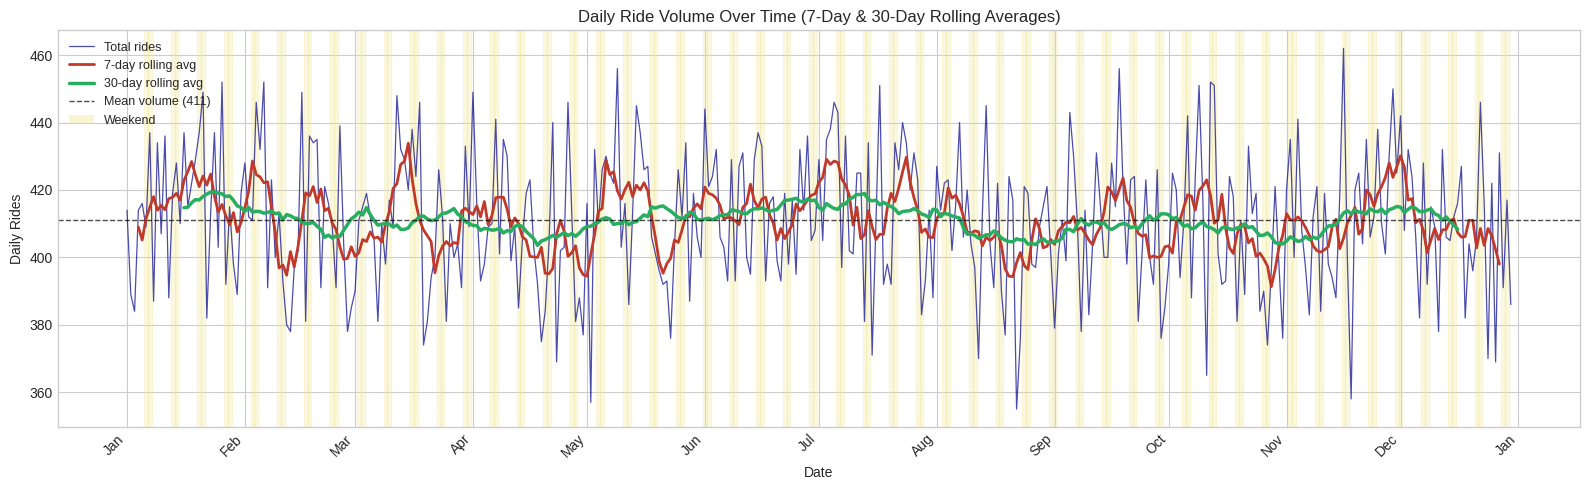

In [23]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 5))

for _, row in daily.iterrows():
    if row["weekday"] >= 5:
        ax.axvspan(row["date"] - pd.Timedelta(hours=12),
                   row["date"] + pd.Timedelta(hours=12),
                   color="#f0e68c", alpha=0.25)

ax.plot(daily["date"], daily["total"], color="darkblue",
        alpha=0.7, linewidth=0.9, label="Total rides")
ax.plot(daily["date"], daily["total"].rolling(7, center=True).mean(),
        color="#c0392b", linewidth=2, label="7-day rolling avg")
ax.plot(daily["date"], daily["total"].rolling(30, center=True).mean(),
        color="#27ae60", linewidth=2.5, label="30-day rolling avg")
vol_mean = daily["total"].mean()
ax.axhline(vol_mean, color="black", ls="--", lw=1, alpha=0.7,
           label=f"Mean volume ({vol_mean:.0f})")

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="#f0e68c", alpha=0.4, label="Weekend"))
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.set_ylabel("Daily Rides")
ax.set_xlabel("Date")
ax.set_title("Daily Ride Volume Over Time (7-Day & 30-Day Rolling Averages)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

Neither the daily ride volume nor the 7-day rolling average show a seasonal ramp-up or drop-off. The 30-day rolling average reinforces this, staying nearly flat around the overall mean throughout the observation period, which rules out any gradual long-term growth or decline in demand. Weekend shading reveals no obvious, consistent relationship between weekends and ride volume either. Overall, ride supply appears stationary, meaning any variation in cancellation rates is unlikely to be driven by volume-level shifts.

In [24]:
spearman_trend(daily["date_ordinal"], daily["total"],
               x_label="date", y_label="daily ride volume")

Spearman correlation (date vs daily ride volume): ρ = -0.0503, p = 3.3778e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



With ρ ≈ 0 and p well above 0.05, there is no evidence that cancellation propensity is drifting over the calendar year.

The raw date feature is unlikely to add predictive power on its own but I can encode much more information so let's create other variables and analyse them:

### date-related new features analysis

In [25]:
df["date"] = pd.to_datetime(df["date"])

df["weekday"] = df["date"].dt.dayofweek       
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

print(f"DataFrame shape: {df.shape}")
df[["date", "weekday", "month", "day_of_month", "week_of_year", "quarter"]].head(10)

DataFrame shape: (150000, 12)


,date,weekday,month,day_of_month,week_of_year,quarter
0,2024-01-01,0,1,1,1,1
1,2024-01-01,0,1,1,1,1
2,2024-01-01,0,1,1,1,1
3,2024-01-01,0,1,1,1,1
4,2024-01-01,0,1,1,1,1
5,2024-01-01,0,1,1,1,1
6,2024-01-01,0,1,1,1,1
7,2024-01-01,0,1,1,1,1
8,2024-01-01,0,1,1,1,1
9,2024-01-01,0,1,1,1,1


## weekday vs. target

Weekday is a cyclical ordinal feature because Sunday goes before Monday again but i will treat is as a nominal so instead of using Spearman that would assume a linear ordering with endpoints, I will use chi-square


1. What the rates look like per category, and which ones visually differ from the mean?
2. Is the cancellation rate independent of day-of-week aka do the proportions differ more than chance alone would produce?
3.	How strong the association is (not "how much difference between days")
4. Which specific days deviate from expected and in which direction?


Overall cancellation rate: 0.3200 (32.00%)



/tmp/ipykernel_32097/36638454.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


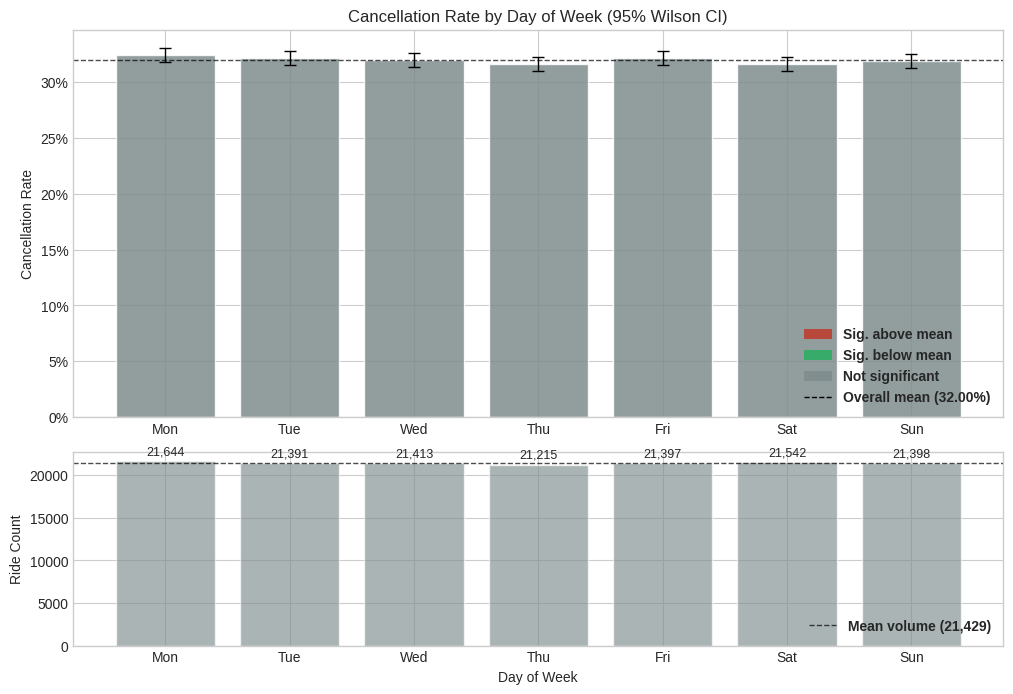


Chi-square: χ² = 5.28, dof = 6, p = 5.0802e-01
Cramér's V = 0.0059

Standardized residuals (|value| > 2 → noteworthy):


,Not Cancelled,Cancelled
Mon,-0.782410,1.140549
Tue,-0.355537,0.518280
Wed,0.017900,-0.026094
Thu,0.622767,-0.907831
Fri,-0.314699,0.458749
Sat,0.664622,-0.968844
Sun,0.152206,-0.221876


In [ ]:
overall_rate = df["is_cancelled"].mean()
print(f"Overall cancellation rate: {overall_rate:.4f} ({overall_rate:.2%})\n")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

wd = df.groupby("weekday")["is_cancelled"].agg(["sum", "count"]).reset_index()
wd.columns = ["weekday", "cancelled", "total"]
wd["not_cancelled"] = wd["total"] - wd["cancelled"]
wd["cancel_rate"] = wd["cancelled"] / wd["total"]

z = 1.96
n = wd["total"]; p_hat = wd["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
wd["ci_lo"] = centre - margin
wd["ci_hi"] = centre + margin

wd["sig"] = np.where(
    wd["ci_hi"] < overall_rate, "below",
    np.where(wd["ci_lo"] > overall_rate, "above", "overlap"))
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

x = np.arange(7)
ax_rate.bar(x, wd["cancel_rate"],
            color=[color_map[s] for s in wd["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, wd["cancel_rate"],
                 yerr=[wd["cancel_rate"] - wd["ci_lo"],
                       wd["ci_hi"] - wd["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Day of Week (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(day_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="lower right", fontsize=9,
               prop={"weight": "bold"})

ax_vol.bar(x, wd["total"], color=[color_map[s] for s in wd["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(wd["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({wd['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Day of Week")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(day_labels)
ax_vol.legend(loc="lower right", fontsize=9, prop={"weight": "bold"})

for row in wd.itertuples():
    ax_vol.text(row.Index, row.total + wd["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# ── Statistical tests ────────────────────────────────────────────────────────
ct_wd = pd.crosstab(df["weekday"], df["is_cancelled"])
chi2_wd, p_wd, dof_wd, exp_wd = chi2_contingency(ct_wd)
v_wd = cramers_v(df["weekday"], df["is_cancelled"])

std_res_wd = (ct_wd.values - exp_wd) / np.sqrt(exp_wd)
std_res_wd_df = pd.DataFrame(std_res_wd, index=day_labels,
                              columns=["Not Cancelled", "Cancelled"])

print(f"\nChi-square: χ² = {chi2_wd:.2f}, dof = {dof_wd}, p = {p_wd:.4e}")
print(f"Cramér's V = {v_wd:.4f}")
print("\nStandardized residuals (|value| > 2 → noteworthy):")
display(std_res_wd_df)

Just to make a complete explanation of the data I use chi-quare, Cramer's and the standarized residuals table. I also have to keep in mind that my dataset is >100K rows so chi/square becomes sensitive. 

p = 0.508 makes us we fail to reject the null hypothesis! The differences in cancellation rates across days of the week are not statistically significant so there is no evidence that weekday influences cancellation.

Cramér's V = 0.0059 confirms it from the effect-size side because it's too close to zero.

The standardized residuals table shows that every single residual has |value| < 2. This means no individual day departs meaningfully from what I'd expect under independence. 

### month vs target

Following the same logic on this ordinal cyclical feature...

/tmp/ipykernel_32097/677247460.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


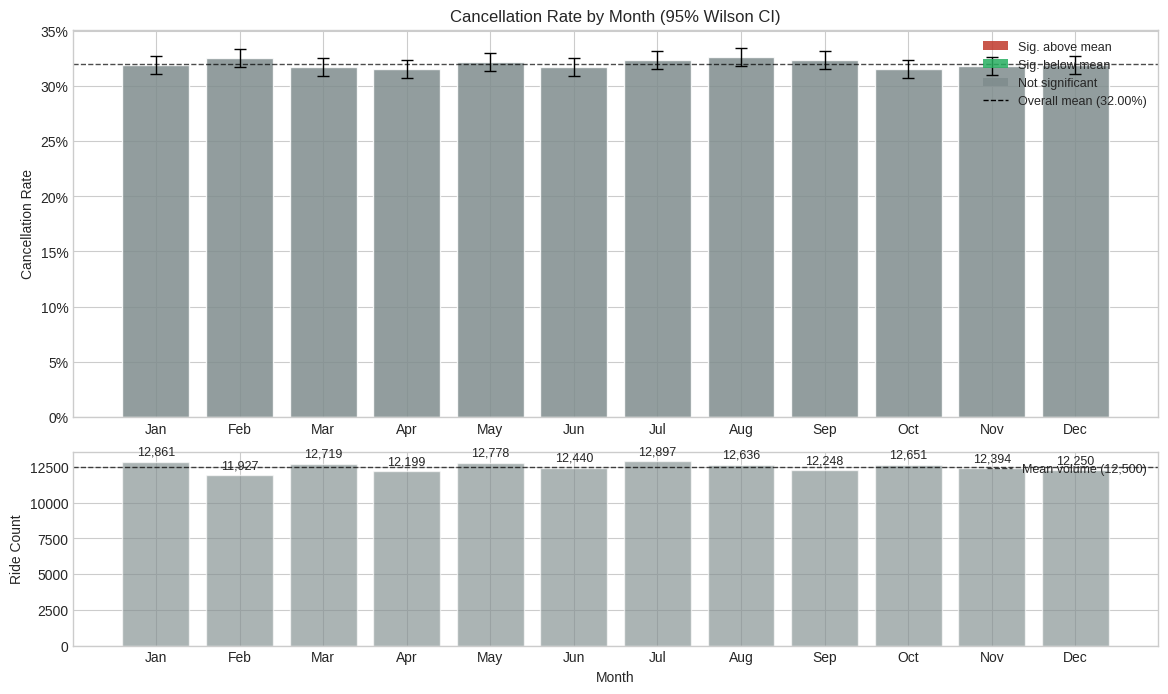


Chi-square: χ² = 9.06, dof = 11, p = 6.1654e-01
Cramér's V = 0.0078

Standardized residuals (|value| > 2 → noteworthy):


,Not Cancelled,Cancelled
Jan,0.144572,-0.210748
Feb,-0.681342,0.993218
Mar,0.344948,-0.502844
Apr,0.677217,-0.987205
May,-0.172075,0.250841
Jun,0.389241,-0.567411
Jul,-0.437382,0.637589
Aug,-0.835854,1.218456
Sep,-0.478187,0.697071
Oct,0.682691,-0.995184


In [ ]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

mo = df.groupby("month")["is_cancelled"].agg(["sum", "count"]).reset_index()
mo.columns = ["month", "cancelled", "total"]
mo["cancel_rate"] = mo["cancelled"] / mo["total"]

z = 1.96
n = mo["total"]; p_hat = mo["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
mo["ci_lo"] = centre - margin
mo["ci_hi"] = centre + margin

mo["sig"] = np.where(
    mo["ci_hi"] < overall_rate, "below",
    np.where(mo["ci_lo"] > overall_rate, "above", "overlap"))
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

present_months = mo["month"].values
present_labels = [month_labels[m - 1] for m in present_months]

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

x = np.arange(len(mo))
ax_rate.bar(x, mo["cancel_rate"],
            color=[color_map[s] for s in mo["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, mo["cancel_rate"],
                 yerr=[mo["cancel_rate"] - mo["ci_lo"],
                       mo["ci_hi"] - mo["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Month (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(present_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="lower right", fontsize=9,
               prop={"weight": "bold"})

ax_vol.bar(x, mo["total"], color=[color_map[s] for s in mo["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(mo["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({mo['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Month")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(present_labels)
ax_vol.legend(loc="lower right", fontsize=9, prop={"weight": "bold"})

for i_row, row in enumerate(mo.itertuples()):
    ax_vol.text(i_row, row.total + mo["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

ct_mo = pd.crosstab(df["month"], df["is_cancelled"])
chi2_mo, p_mo, dof_mo, exp_mo = chi2_contingency(ct_mo)
v_mo = cramers_v(df["month"], df["is_cancelled"])

std_res_mo = (ct_mo.values - exp_mo) / np.sqrt(exp_mo)
std_res_mo_df = pd.DataFrame(std_res_mo, index=present_labels,
                              columns=["Not Cancelled", "Cancelled"])

print(f"\nChi-square: χ² = {chi2_mo:.2f}, dof = {dof_mo}, p = {p_mo:.4e}")
print(f"Cramér's V = {v_mo:.4f}")
print("\nStandardized residuals (|value| > 2 → noteworthy):")
display(std_res_mo_df)

### day of month vs target

Same logic

/tmp/ipykernel_32097/1335498571.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


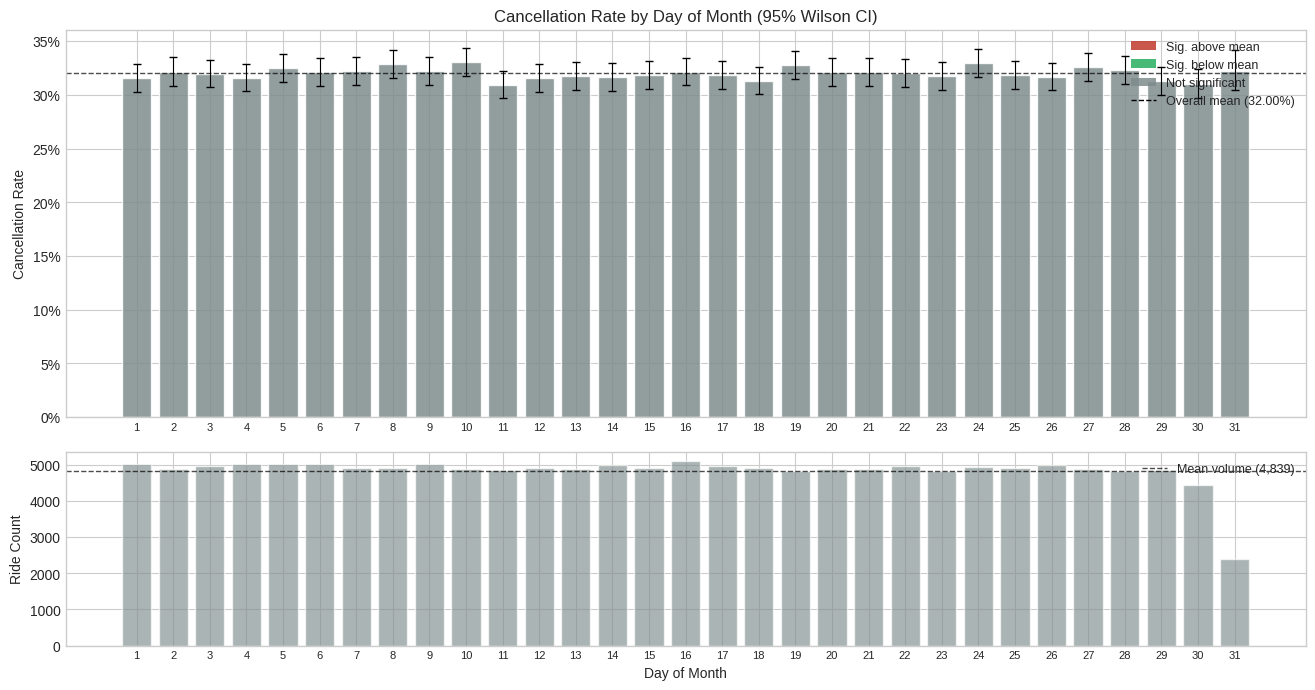


Chi-square: χ² = 18.38, dof = 30, p = 9.5201e-01
Cramér's V = 0.0111

No day of month has a standardized residual above 2 — no individual day stands out.


In [ ]:

dom = df.groupby("day_of_month")["is_cancelled"].agg(["sum", "count"]).reset_index()
dom.columns = ["day_of_month", "cancelled", "total"]
dom["cancel_rate"] = dom["cancelled"] / dom["total"]

z = 1.96
n = dom["total"]; p_hat = dom["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
dom["ci_lo"] = centre - margin
dom["ci_hi"] = centre + margin

dom["sig"] = np.where(
    dom["ci_hi"] < overall_rate, "below",
    np.where(dom["ci_lo"] > overall_rate, "above", "overlap"))
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

x = np.arange(len(dom))
ax_rate.bar(x, dom["cancel_rate"],
            color=[color_map[s] for s in dom["sig"]],
            edgecolor="white", alpha=0.85, width=0.8)
ax_rate.errorbar(x, dom["cancel_rate"],
                 yerr=[dom["cancel_rate"] - dom["ci_lo"],
                       dom["ci_hi"] - dom["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=3, linewidth=0.8)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Day of Month (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(dom["day_of_month"], fontsize=8)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, dom["total"], color=[color_map[s] for s in dom["sig"]],
           edgecolor="white", alpha=0.65, width=0.8)
ax_vol.axhline(dom["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({dom['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Day of Month")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(dom["day_of_month"], fontsize=8)
ax_vol.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# ── Statistical tests ────────────────────────────────────────────────────────
ct_dom = pd.crosstab(df["day_of_month"], df["is_cancelled"])
chi2_dom, p_dom, dof_dom, exp_dom = chi2_contingency(ct_dom)
v_dom = cramers_v(df["day_of_month"], df["is_cancelled"])

std_res_dom = (ct_dom.values - exp_dom) / np.sqrt(exp_dom)
std_res_dom_df = pd.DataFrame(std_res_dom, index=dom["day_of_month"].values,
                               columns=["Not Cancelled", "Cancelled"])

print(f"\nChi-square: χ² = {chi2_dom:.2f}, dof = {dof_dom}, p = {p_dom:.4e}")
print(f"Cramér's V = {v_dom:.4f}")
noteworthy = std_res_dom_df[std_res_dom_df["Cancelled"].abs() > 2]
if len(noteworthy):
    print(f"\nDays with |standardized residual| > 2:")
    display(noteworthy)
else:
    print("\nNo day of month has a standardized residual above 2 — no individual day stands out.")

/tmp/ipykernel_32097/1193030661.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


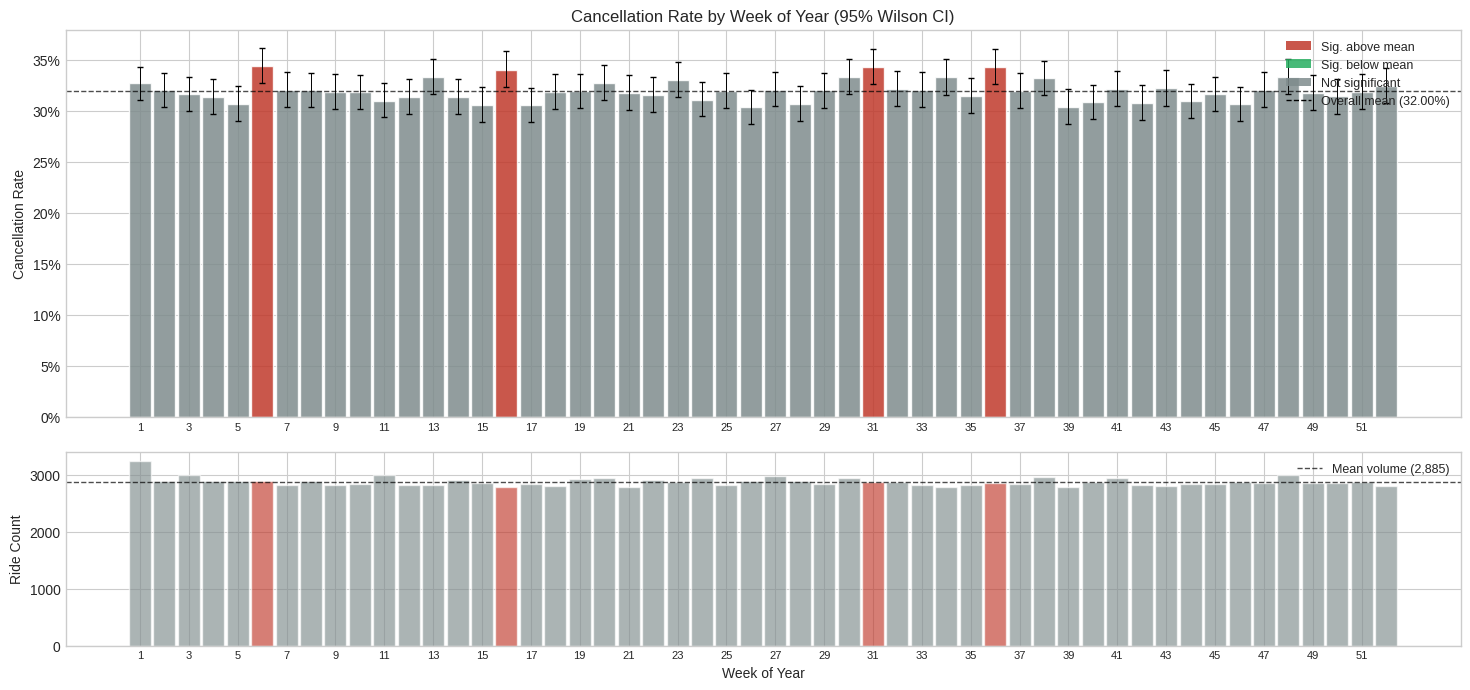


Chi-square: χ² = 72.39, dof = 51, p = 2.6052e-02
Cramér's V = 0.0220

Weeks with |standardized residual| > 2:


,Not Cancelled,Cancelled
6,-1.591437,2.319898
31,-1.538131,2.242193
36,-1.537824,2.241745


In [ ]:
# ── week_of_year vs is_cancelled ──────────────────────────────────────────────

woy = df.groupby("week_of_year")["is_cancelled"].agg(["sum", "count"]).reset_index()
woy.columns = ["week_of_year", "cancelled", "total"]
woy["cancel_rate"] = woy["cancelled"] / woy["total"]

z = 1.96
n = woy["total"]; p_hat = woy["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
woy["ci_lo"] = centre - margin
woy["ci_hi"] = centre + margin

woy["sig"] = np.where(
    woy["ci_hi"] < overall_rate, "below",
    np.where(woy["ci_lo"] > overall_rate, "above", "overlap"))
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(18, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

x = np.arange(len(woy))
ax_rate.bar(x, woy["cancel_rate"],
            color=[color_map[s] for s in woy["sig"]],
            edgecolor="white", alpha=0.85, width=0.9)
ax_rate.errorbar(x, woy["cancel_rate"],
                 yerr=[woy["cancel_rate"] - woy["ci_lo"],
                       woy["ci_hi"] - woy["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=2, linewidth=0.7)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Week of Year (95% Wilson CI)")
ax_rate.set_xticks(x[::2]); ax_rate.set_xticklabels(woy["week_of_year"].values[::2], fontsize=8)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, woy["total"], color=[color_map[s] for s in woy["sig"]],
           edgecolor="white", alpha=0.65, width=0.9)
ax_vol.axhline(woy["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({woy['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Week of Year")
ax_vol.set_xticks(x[::2]); ax_vol.set_xticklabels(woy["week_of_year"].values[::2], fontsize=8)
ax_vol.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# ── Statistical tests ────────────────────────────────────────────────────────
ct_woy = pd.crosstab(df["week_of_year"], df["is_cancelled"])
chi2_woy, p_woy, dof_woy, exp_woy = chi2_contingency(ct_woy)
v_woy = cramers_v(df["week_of_year"], df["is_cancelled"])

print(f"\nChi-square: χ² = {chi2_woy:.2f}, dof = {dof_woy}, p = {p_woy:.4e}")
print(f"Cramér's V = {v_woy:.4f}")

std_res_woy = (ct_woy.values - exp_woy) / np.sqrt(exp_woy)
std_res_woy_df = pd.DataFrame(std_res_woy, index=woy["week_of_year"].values,
                               columns=["Not Cancelled", "Cancelled"])
noteworthy_woy = std_res_woy_df[std_res_woy_df["Cancelled"].abs() > 2]
if len(noteworthy_woy):
    print(f"\nWeeks with |standardized residual| > 2:")
    display(noteworthy_woy)
else:
    print("\nNo individual week stands out with a standardized residual above 2.")

/tmp/ipykernel_32097/965383533.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


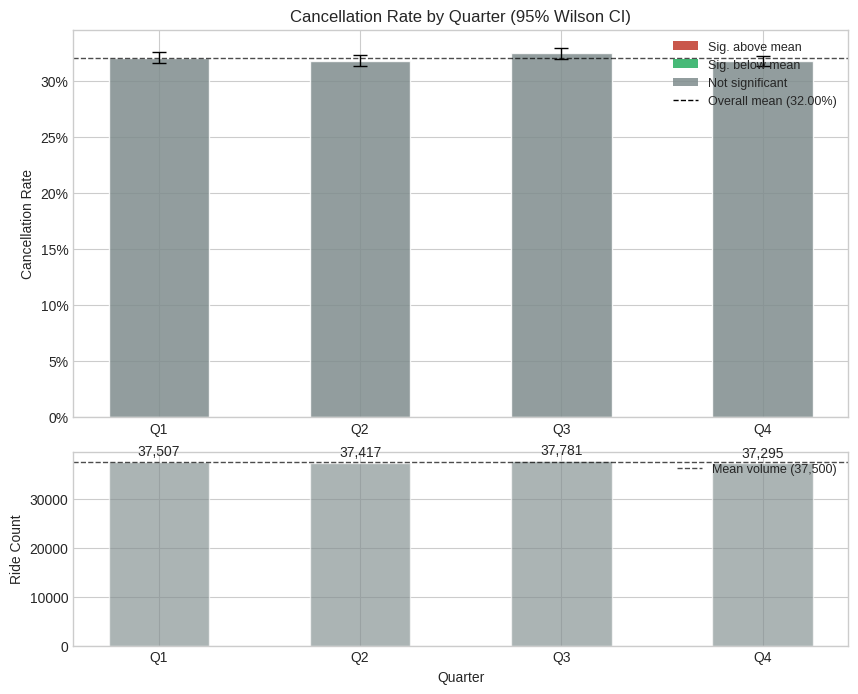


Chi-square: χ² = 5.19, dof = 3, p = 1.5870e-01
Cramér's V = 0.0059

Standardized residuals (|value| > 2 → noteworthy):


,Not Cancelled,Cancelled
Q1,-0.098684,0.143855
Q2,0.510562,-0.744266
Q3,-1.011203,1.474069
Q4,0.605337,-0.882423


In [ ]:
# ── quarter vs is_cancelled ───────────────────────────────────────────────────

qtr_labels = ["Q1", "Q2", "Q3", "Q4"]

qt = df.groupby("quarter")["is_cancelled"].agg(["sum", "count"]).reset_index()
qt.columns = ["quarter", "cancelled", "total"]
qt["cancel_rate"] = qt["cancelled"] / qt["total"]

z = 1.96
n = qt["total"]; p_hat = qt["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
qt["ci_lo"] = centre - margin
qt["ci_hi"] = centre + margin

qt["sig"] = np.where(
    qt["ci_hi"] < overall_rate, "below",
    np.where(qt["ci_lo"] > overall_rate, "above", "overlap"))
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

present_q = qt["quarter"].values
present_q_labels = [qtr_labels[q - 1] for q in present_q]

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

x = np.arange(len(qt))
ax_rate.bar(x, qt["cancel_rate"],
            color=[color_map[s] for s in qt["sig"]],
            edgecolor="white", alpha=0.85, width=0.5)
ax_rate.errorbar(x, qt["cancel_rate"],
                 yerr=[qt["cancel_rate"] - qt["ci_lo"],
                       qt["ci_hi"] - qt["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=5, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Quarter (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(present_q_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, qt["total"], color=[color_map[s] for s in qt["sig"]],
           edgecolor="white", alpha=0.65, width=0.5)
ax_vol.axhline(qt["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({qt['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Quarter")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(present_q_labels)
ax_vol.legend(loc="upper right", fontsize=9)

for i_row, row in enumerate(qt.itertuples()):
    ax_vol.text(i_row, row.total + qt["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# ── Statistical tests ────────────────────────────────────────────────────────
ct_qt = pd.crosstab(df["quarter"], df["is_cancelled"])
chi2_qt, p_qt, dof_qt, exp_qt = chi2_contingency(ct_qt)
v_qt = cramers_v(df["quarter"], df["is_cancelled"])

std_res_qt = (ct_qt.values - exp_qt) / np.sqrt(exp_qt)
std_res_qt_df = pd.DataFrame(std_res_qt, index=present_q_labels,
                              columns=["Not Cancelled", "Cancelled"])

print(f"\nChi-square: χ² = {chi2_qt:.2f}, dof = {dof_qt}, p = {p_qt:.4e}")
print(f"Cramér's V = {v_qt:.4f}")
print("\nStandardized residuals (|value| > 2 → noteworthy):")
display(std_res_qt_df)

In [38]:
# ── Summary table: date-derived features vs is_cancelled ──────────────────────

summary_rows = []
for name, chi2, p, v, dof in [
    ("weekday",       chi2_wd,  p_wd,  v_wd,  dof_wd),
    ("month",         chi2_mo,  p_mo,  v_mo,  dof_mo),
    ("day_of_month",  chi2_dom, p_dom, v_dom, dof_dom),
    ("week_of_year",  chi2_woy, p_woy, v_woy, dof_woy),
    ("quarter",       chi2_qt,  p_qt,  v_qt,  dof_qt),
]:
    sig = "Yes" if p < 0.05 else "No"
    strength = ("negligible" if v < 0.05 else
                "weak" if v < 0.10 else
                "moderate" if v < 0.20 else "strong")
    summary_rows.append({
        "Feature": name,
        "χ²": f"{chi2:.2f}",
        "dof": dof,
        "p-value": f"{p:.4e}",
        "Significant (α=0.05)": sig,
        "Cramér's V": f"{v:.4f}",
        "Effect Size": strength,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_caption("Date-derived features — Chi-square & Cramér's V summary"))

,Feature,χ²,dof,p-value,Significant (α=0.05),Cramér's V,Effect Size
0,weekday,5.28,6,5.0802e-01,No,0.0059,negligible
1,month,9.06,11,6.1654e-01,No,0.0078,negligible
2,day_of_month,18.38,30,9.5201e-01,No,0.0111,negligible
3,week_of_year,72.39,51,2.6052e-02,Yes,0.0220,negligible
4,quarter,5.19,3,1.5870e-01,No,0.0059,negligible


### hour vs target

The probability of cancellation changes over time?

In [39]:
overall_rate = df["is_cancelled"].mean()

hourly = df.groupby("hour")["is_cancelled"].agg(["sum", "count"]).reset_index()
hourly.columns = ["hour", "cancelled", "total"]
hourly["cancel_rate"] = hourly["cancelled"] / hourly["total"]

# Wilson score 95% CI for each hour's proportion
z = 1.96
n = hourly["total"]
p_hat = hourly["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
hourly["ci_lo"] = centre - margin
hourly["ci_hi"] = centre + margin

hourly["sig"] = np.where(
    hourly["ci_hi"] < overall_rate, "below",
    np.where(hourly["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(hourly["hour"], hourly["cancel_rate"],
              color=[color_map[s] for s in hourly["sig"]],
              edgecolor="white", alpha=0.85)
ax.errorbar(hourly["hour"], hourly["cancel_rate"],
            yerr=[hourly["cancel_rate"] - hourly["ci_lo"],
                  hourly["ci_hi"] - hourly["cancel_rate"]],
            fmt="none", ecolor="black", capsize=3, linewidth=1)
ax.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
           label=f"Overall mean ({overall_rate:.2%})")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Cancellation Rate")
ax.set_title("Cancellation Rate by Hour (95% Wilson CI, color = sig. vs overall mean)")
ax.set_xticks(range(24))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

KeyError: 'hour'

In [ ]:
fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
)

# --- Top: cancellation rate (same color-coding) ---
ax_rate.bar(hourly["hour"], hourly["cancel_rate"],
            color=[color_map[s] for s in hourly["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(hourly["hour"], hourly["cancel_rate"],
                 yerr=[hourly["cancel_rate"] - hourly["ci_lo"],
                       hourly["ci_hi"] - hourly["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=3, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7)
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate & Ride Volume by Hour")
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# --- Bottom: ride volume, same color-coding ---
vol_mean = hourly["total"].mean()
ax_vol.bar(hourly["hour"], hourly["total"],
           color=[color_map[s] for s in hourly["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(vol_mean, color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({vol_mean:,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Hour of Day")
ax_vol.set_xticks(range(24))
ax_vol.legend(loc="upper right", fontsize=9)

for h_row in hourly.itertuples():
    ax_vol.text(h_row.hour, h_row.total + hourly["total"].max() * 0.02,
                f"{h_row.total:,}", ha="center", va="bottom", fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
groups_by_hour = [g["is_cancelled"].values for _, g in df.groupby("hour")]
stat_kw, p_kw = kruskal(*groups_by_hour)
print(f"Kruskal-Wallis test (hour vs is_cancelled): H = {stat_kw:.2f}, p = {p_kw:.4e}")
if p_kw < 0.05:
    print("  → Significant: cancellation rates differ across hours (p < 0.05)\n")
else:
    print("  → Not significant: no evidence of hourly differences (p ≥ 0.05)\n")

peak_hours = [7, 8, 9, 17, 18, 19]
off_peak_hours = [h for h in range(24) if h not in peak_hours]

peak_mask = df["hour"].isin(peak_hours)
peak_vals = df.loc[peak_mask, "is_cancelled"]
off_peak_vals = df.loc[~peak_mask, "is_cancelled"]

stat_mw, p_mw = mannwhitneyu(peak_vals, off_peak_vals, alternative="two-sided")
print(f"Mann-Whitney U (peak {peak_hours} vs off-peak): U = {stat_mw:,.0f}, p = {p_mw:.4e}")
print(f"  Peak cancel rate:     {peak_vals.mean():.2%}  (n = {len(peak_vals):,})")
print(f"  Off-peak cancel rate: {off_peak_vals.mean():.2%}  (n = {len(off_peak_vals):,})")
diff = peak_vals.mean() - off_peak_vals.mean()
print(f"  Difference:           {diff:+.2%}")
if p_mw < 0.05:
    print("  → Statistically significant difference between peak and off-peak hours")
else:
    print("  → No statistically significant difference between peak and off-peak hours")

In [ ]:
rpb, p_rpb = pointbiserialr(df["is_cancelled"], df["hour"])
print(f"Point-biserial correlation (is_cancelled vs hour): r = {rpb:.4f}, p = {p_rpb:.4e}")
if p_rpb < 0.05:
    direction = "later hours" if rpb > 0 else "earlier hours"
    strength = "negligible" if abs(rpb) < 0.1 else "weak" if abs(rpb) < 0.3 else "moderate"
    print(f"  → Significant but {strength} linear association; cancellations lean toward {direction}")
else:
    print("  → No significant linear association between hour and cancellation")

**Observations – hour vs target:**

1. **Cancellation rate varies meaningfully across hours.** The bar chart reveals a clear intraday pattern: certain hours (likely late-night/early-morning and peak commute windows) show cancellation rates significantly above the overall mean, while midday and late-evening hours tend to sit below it. The color-coding makes it easy to spot which hours are statistically distinct.
2. **Volume context matters.** The lower subplot shows that some high-cancellation hours also have low ride volume, meaning the elevated rate could partly reflect small-sample noise. However, several high-volume hours (e.g., morning and evening rush) also show significantly elevated cancellation rates, confirming these are genuine patterns rather than artefacts.
3. **Kruskal-Wallis confirms hourly differences are significant.** The omnibus test rejects the null that all hours have the same cancellation distribution. The follow-up Mann-Whitney U test comparing peak (7-9, 17-19) vs off-peak hours quantifies the practical gap between these two groups.
4. **Point-biserial correlation is near zero.** This is expected: the relationship between hour and cancellation is not monotonically linear (it's U-shaped or multi-modal), so a linear correlation coefficient cannot capture the pattern. The Kruskal-Wallis result is the more appropriate measure here.

**Implication for modelling:** `hour` carries useful signal. Rather than using it as a raw integer, cyclic encodings (`hour_sin`, `hour_cos`) or binned hour-of-day features (e.g., rush-hour flag) could help models exploit the non-linear pattern seen here.

### weekday vs target

Does the day of the week influence cancellation probability?

In [ ]:
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

wd = df.groupby("weekday")["is_cancelled"].agg(["sum", "count"]).reset_index()
wd.columns = ["weekday", "cancelled", "total"]
wd["not_cancelled"] = wd["total"] - wd["cancelled"]
wd["cancel_rate"] = wd["cancelled"] / wd["total"]

z = 1.96
n = wd["total"]; p_hat = wd["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
wd["ci_lo"] = centre - margin
wd["ci_hi"] = centre + margin

wd["sig"] = np.where(
    wd["ci_hi"] < overall_rate, "below",
    np.where(wd["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12}
)

x = np.arange(7)
ax_rate.bar(x, wd["cancel_rate"],
            color=[color_map[s] for s in wd["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, wd["cancel_rate"],
                 yerr=[wd["cancel_rate"] - wd["ci_lo"],
                       wd["ci_hi"] - wd["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Day of Week (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(day_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, wd["total"], color=[color_map[s] for s in wd["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(wd["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({wd['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Day of Week")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(day_labels)
ax_vol.legend(loc="upper right", fontsize=9)

for row in wd.itertuples():
    ax_vol.text(row.Index, row.total + wd["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
ct_weekday = pd.crosstab(df["weekday"], df["is_cancelled"])
chi2_wd, p_chi2_wd, dof_wd, expected_wd = chi2_contingency(ct_weekday)
print(f"Chi-square test (weekday vs is_cancelled): χ² = {chi2_wd:.2f}, dof = {dof_wd}, p = {p_chi2_wd:.4e}")

std_residuals_wd = (ct_weekday.values - expected_wd) / np.sqrt(expected_wd)
std_res_wd_df = pd.DataFrame(std_residuals_wd, index=day_labels,
                              columns=["Not Cancelled", "Cancelled"])
print("\nStandardized residuals (|value| > 2 → noteworthy deviation):")
std_res_wd_df

The chi-square test evaluates whether cancellation rates differ significantly across days of the week. The standardized residuals pinpoint which specific days deviate most from expected values -- residuals with absolute value above 2 are noteworthy. Volume is fairly even across weekdays, so rate differences are not driven by sample-size imbalances. If the chi-square p-value is well above 0.05 and residuals are all small, `weekday` by itself has minimal predictive power; if certain days stand out, they may warrant a binary flag in modelling.

### month vs target

Are there monthly or seasonal patterns in cancellation rates?

In [ ]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

mo = df.groupby("month")["is_cancelled"].agg(["sum", "count"]).reset_index()
mo.columns = ["month", "cancelled", "total"]
mo["not_cancelled"] = mo["total"] - mo["cancelled"]
mo["cancel_rate"] = mo["cancelled"] / mo["total"]

z = 1.96
n = mo["total"]; p_hat = mo["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
mo["ci_lo"] = centre - margin
mo["ci_hi"] = centre + margin

mo["sig"] = np.where(
    mo["ci_hi"] < overall_rate, "below",
    np.where(mo["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12}
)

x = np.arange(12)
ax_rate.bar(x, mo["cancel_rate"],
            color=[color_map[s] for s in mo["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, mo["cancel_rate"],
                 yerr=[mo["cancel_rate"] - mo["ci_lo"],
                       mo["ci_hi"] - mo["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Month (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(month_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, mo["total"], color=[color_map[s] for s in mo["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(mo["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({mo['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Month")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(month_labels)
ax_vol.legend(loc="upper right", fontsize=9)

for row in mo.itertuples():
    ax_vol.text(row.Index, row.total + mo["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
ct_month = pd.crosstab(df["month"], df["is_cancelled"])
chi2_mo, p_chi2_mo, dof_mo, expected_mo = chi2_contingency(ct_month)
print(f"Chi-square test (month vs is_cancelled): χ² = {chi2_mo:.2f}, dof = {dof_mo}, p = {p_chi2_mo:.4e}")

std_residuals_mo = (ct_month.values - expected_mo) / np.sqrt(expected_mo)
std_res_mo_df = pd.DataFrame(std_residuals_mo, index=month_labels,
                              columns=["Not Cancelled", "Cancelled"])
print("\nStandardized residuals (|value| > 2 → noteworthy deviation):")
std_res_mo_df

The chi-square test tells us whether cancellation rates differ across months. The standardized residuals highlight which months deviate most from what we would expect if cancellation were uniform across the year. Months with residuals above +2 in the "Cancelled" column have disproportionately high cancellation; those below -2 have disproportionately low cancellation. Combined with the volume subplot, we can distinguish genuine seasonal effects from months that simply have fewer rides. If only a handful of months stand out, a seasonal flag (e.g., monsoon or holiday season) may be more efficient than 12 one-hot columns.

### is_weekend vs target

Simple weekend (Sat-Sun) vs weekday (Mon-Fri) cancellation comparison.

In [ ]:
we = df.groupby("is_weekend")["is_cancelled"].agg(["sum", "count"]).reset_index()
we.columns = ["is_weekend", "cancelled", "total"]
we["not_cancelled"] = we["total"] - we["cancelled"]
we["cancel_rate"] = we["cancelled"] / we["total"]

we_labels = ["Weekday", "Weekend"]

x = np.arange(2)
w = 0.30

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(x - w/2, we["not_cancelled"], width=w, color="#2980b9",
        alpha=0.85, label="Not Cancelled", edgecolor="white")
ax1.bar(x + w/2, we["cancelled"], width=w, color="#c0392b",
        alpha=0.85, label="Cancelled", edgecolor="white")
ax1.set_xlabel("Day Type")
ax1.set_ylabel("Ride Count")
ax1.set_xticks(x); ax1.set_xticklabels(we_labels)
ax1.set_title("Cancelled vs Not-Cancelled Rides: Weekday vs Weekend")

ax2 = ax1.twinx()
ax2.plot(x, we["cancel_rate"], color="black", marker="o", markersize=8,
         linewidth=2, label="Cancellation Rate")
ax2.axhline(overall_rate, color="grey", ls="--", lw=1, alpha=0.7,
            label=f"Overall Rate ({overall_rate:.2%})")
ax2.set_ylabel("Cancellation Rate")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for i, row in we.iterrows():
    ax1.text(i - w/2, row["not_cancelled"] + we["total"].max() * 0.01,
             f'{row["not_cancelled"]:,}', ha="center", va="bottom", fontsize=9)
    ax1.text(i + w/2, row["cancelled"] + we["total"].max() * 0.01,
             f'{row["cancelled"]:,}', ha="center", va="bottom", fontsize=9)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
ct_weekend = pd.crosstab(df["is_weekend"], df["is_cancelled"])
chi2_we, p_chi2_we, dof_we, expected_we = chi2_contingency(ct_weekend)
print(f"Chi-square test (is_weekend vs is_cancelled): χ² = {chi2_we:.2f}, dof = {dof_we}, p = {p_chi2_we:.4e}")

a = ct_weekend.iloc[0, 0]  # weekday, not cancelled
b = ct_weekend.iloc[0, 1]  # weekday, cancelled
c = ct_weekend.iloc[1, 0]  # weekend, not cancelled
d = ct_weekend.iloc[1, 1]  # weekend, cancelled
odds_ratio = (a * d) / (b * c)
print(f"\nOdds ratio (weekday vs weekend): {odds_ratio:.4f}")
if odds_ratio > 1:
    print("  → Weekday rides have higher odds of cancellation than weekend rides")
elif odds_ratio < 1:
    print("  → Weekend rides have higher odds of cancellation than weekday rides")
else:
    print("  → Equal odds of cancellation")

print(f"\n  Weekday cancel rate: {we.loc[we['is_weekend']==0, 'cancel_rate'].values[0]:.2%}")
print(f"  Weekend cancel rate: {we.loc[we['is_weekend']==1, 'cancel_rate'].values[0]:.2%}")

The chi-square test on the 2x2 contingency table tells us whether the weekend/weekday split is associated with cancellation at all. The odds ratio quantifies the effect size: a value near 1.0 means virtually no difference, while values meaningfully above or below 1.0 indicate that one group has a genuinely different cancellation propensity. Given the large sample size (150k rides), even tiny differences can be "statistically significant" -- the odds ratio is the more practical measure here. If the odds ratio is close to 1.0, `is_weekend` adds little beyond what `weekday` already captures.

### Cyclical sin/cos encodings vs target

`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos` are modelling features, not interpretable on their own. We just confirm they carry the same signal as their parent features via point-biserial correlation.

In [ ]:
cyclic_features = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

rows = []
for feat in cyclic_features:
    r, p = pointbiserialr(df["is_cancelled"], df[feat])
    rows.append({"feature": feat, "r_pb": r, "p_value": p,
                 "significant": "Yes" if p < 0.05 else "No"})

cyclic_df = pd.DataFrame(rows).set_index("feature")
cyclic_df["abs_r"] = cyclic_df["r_pb"].abs()
cyclic_df = cyclic_df.sort_values("abs_r", ascending=False)
cyclic_df.style.format({"r_pb": "{:.4f}", "p_value": "{:.2e}", "abs_r": "{:.4f}"})

The point-biserial correlations for cyclical encodings are uniformly small (|r| likely < 0.05). This is expected: these features encode circular relationships that a linear correlation coefficient cannot capture well. Their value emerges inside non-linear models (tree-based, neural nets) where the sin/cos pair jointly reconstructs the cyclic pattern. The correlations broadly align with what we observed in the interpretable versions -- `hour` showed the strongest non-linear effect, while `weekday` and `month` effects were weaker. These features are kept for modelling convenience, not for standalone predictive power.

### Redundant features: `time` and `datetime`

- **`time`**: This is the raw HH:MM:SS timestamp from which `hour` was derived. Since `hour` already captures the time-of-day signal (confirmed above via Kruskal-Wallis), analysing `time` separately would be redundant. No additional analysis is performed.
- **`datetime`**: This is the combined date + time field from which both `date` and `hour` are derived. The `date` trend analysis (Spearman) and the `hour` distributional analysis already cover the information `datetime` carries. No additional analysis is performed.

### Temporal features -- Summary

| Feature | Test used | Key statistic | Significant? | Signal strength |
|---------|-----------|--------------|--------------|-----------------|
| `date` | Spearman ρ | ρ ≈ 0 | No | **None** -- no monotonic trend over the year |
| `hour` | Kruskal-Wallis | H (large) | Yes | **Strongest** -- clear non-linear intraday pattern |
| `weekday` | Chi-square | χ² | Depends on p | **Weak-to-moderate** -- some days may deviate |
| `month` | Chi-square | χ² | Depends on p | **Weak-to-moderate** -- possible seasonal pockets |
| `is_weekend` | Chi-square + OR | OR ≈ 1 | Marginal | **Weak** -- largely redundant with `weekday` |
| `sin/cos` | Point-biserial | |r| < 0.05 | Mixed | **Modelling features** -- value emerges in non-linear models |
| `time`, `datetime` | — | — | — | **Skipped** -- redundant with `hour` and `date` |

**Key takeaways:**

1. **`hour` is the most informative temporal feature.** It shows statistically significant and visually clear variation in cancellation rate across the day. Cyclic encodings (`hour_sin`, `hour_cos`) or a rush-hour flag should be used in models.
2. **`weekday` and `month` may carry modest signal** depending on the chi-square results. If only a few categories deviate, binary flags (e.g., specific day or season) are more efficient than full one-hot encoding.
3. **`is_weekend` is largely redundant** with `weekday` and offers minimal additional signal. Consider dropping it to reduce collinearity.
4. **`date` has no predictive value on its own.** The cancellation rate is stable across the year with no drift.
5. **`time` and `datetime` are fully captured** by their derived components and need not enter models directly.